# Car Price Prediction

## Import Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Load Dataset

In [22]:
df = pd.read_csv(r'C:\Users\Manik Sharma\Downloads\New folder (2)\car data.csv')
print(df.shape)
df.head()

(301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [24]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Data Cleaning

In [25]:
# Check missing values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [26]:
# Check and remove duplicates
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 2


In [27]:
# Create new column Car_Age using current year 2024
df['Current_Year'] = 2024
df['Car_Age'] = df['Current_Year'] - df['Year']
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Current_Year,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,2024,10
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,2024,11
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2024,7
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,2024,13
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,2024,10


In [28]:
# Droping columns we don't need
df.drop(columns=['Car_Name', 'Year', 'Current_Year'], inplace=True)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [29]:
# Encode categorical columns
le = LabelEncoder()
df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Seller_Type'] = le.fit_transform(df['Seller_Type'])
df['Transmission'] = le.fit_transform(df['Transmission'])
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,10
1,4.75,9.54,43000,1,0,1,0,11
2,7.25,9.85,6900,2,0,1,0,7
3,2.85,4.15,5200,2,0,1,0,13
4,4.60,6.87,42450,1,0,1,0,10


## EDA (Exploratory Data Analysis)

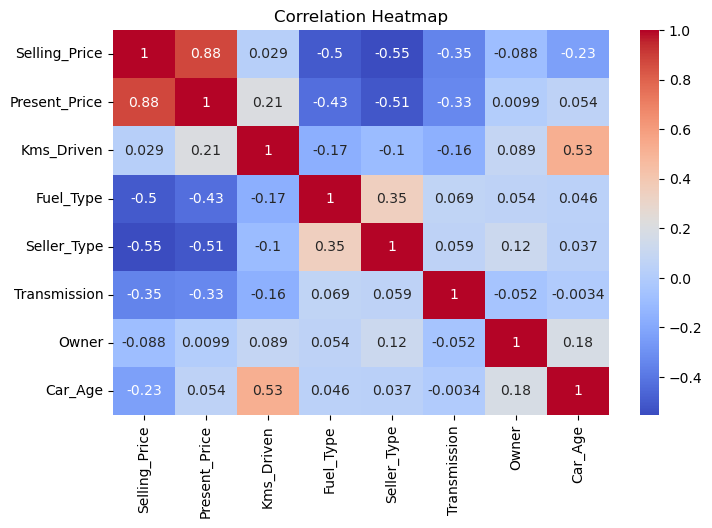

In [30]:
# Correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

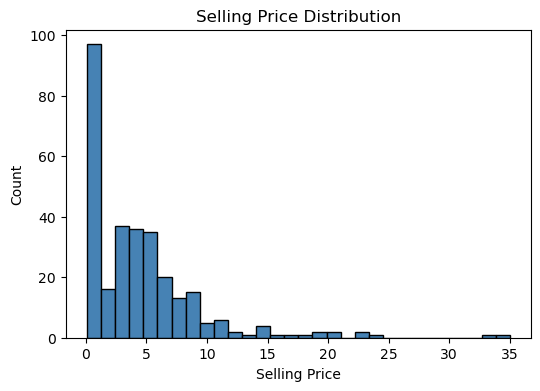

In [31]:
# Distribution of Selling Price
plt.figure(figsize=(6, 4))
plt.hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='black')
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.ylabel('Count')
plt.show()

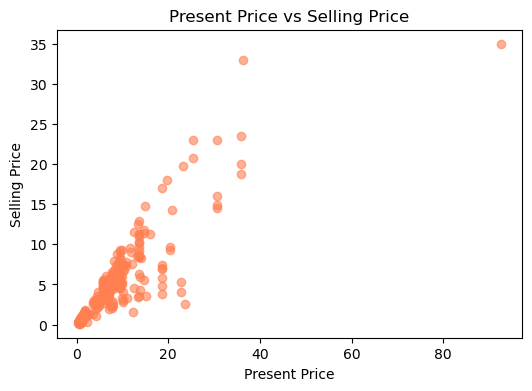

In [32]:
# Selling Price vs Present Price
plt.figure(figsize=(6, 4))
plt.scatter(df['Present_Price'], df['Selling_Price'], alpha=0.6, color='coral')
plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.show()

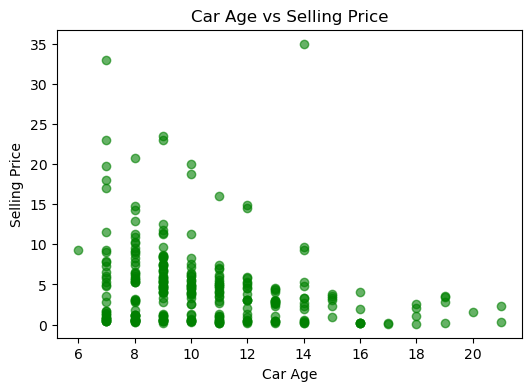

In [33]:
# Car Age vs Selling Price
plt.figure(figsize=(6, 4))
plt.scatter(df['Car_Age'], df['Selling_Price'], alpha=0.6, color='green')
plt.title('Car Age vs Selling Price')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')
plt.show()

## Model Training

In [34]:
# Split features and target
X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 239
Testing samples: 60


In [35]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('Linear Regression')
print('R2 Score:', r2_score(y_test, y_pred_lr))
print('MAE:', mean_absolute_error(y_test, y_pred_lr))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression
R2 Score: 0.7410829335731294
MAE: 1.5410718122837717
RMSE: 2.5832416547485963


In [36]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('Decision Tree')
print('R2 Score:', r2_score(y_test, y_pred_dt))
print('MAE:', mean_absolute_error(y_test, y_pred_dt))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Decision Tree
R2 Score: 0.8382216177868399
MAE: 1.0783333333333331
RMSE: 2.041949232147231


In [37]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest')
print('R2 Score:', r2_score(y_test, y_pred_rf))
print('MAE:', mean_absolute_error(y_test, y_pred_rf))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest
R2 Score: 0.5777259891991424
MAE: 1.400010000000001
RMSE: 3.298996636857941


## Model Comparison

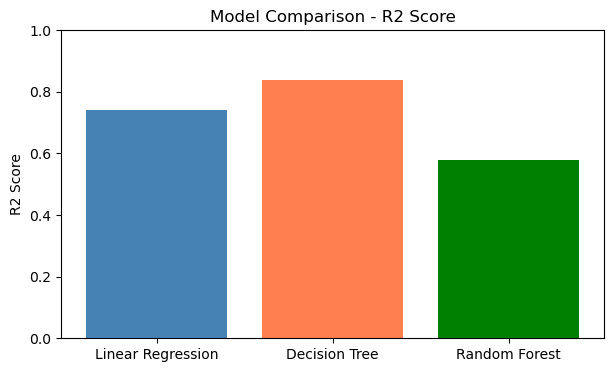

In [38]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

plt.figure(figsize=(7, 4))
plt.bar(models, r2_scores, color=['steelblue', 'coral', 'green'])
plt.title('Model Comparison - R2 Score')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.show()

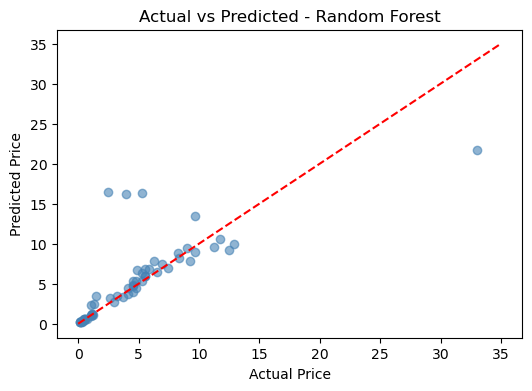

In [39]:
# Actual vs Predicted (Random Forest)
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color='steelblue')
plt.plot([0, 35], [0, 35], 'r--')
plt.title('Actual vs Predicted - Random Forest')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

## Predict on New Data

In [40]:
# Encoding reference:
# Fuel_Type    -> CNG=0, Diesel=1, Petrol=2
# Seller_Type  -> Dealer=0, Individual=1
# Transmission -> Automatic=0, Manual=1

new_car = [[9.5, 45000, 2, 0, 1, 0, 5]]  # Present_Price, Kms_Driven, Fuel, Seller, Trans, Owner, Age

predicted_price = rf.predict(new_car)
print('Predicted Selling Price:', round(predicted_price[0], 2), 'Lakhs')

Predicted Selling Price: 8.13 Lakhs


SUMMARY:
In this project we predicted the selling price of used cars using machine learning.
We started by loading the dataset which had 301 rows and 9 columns. We cleaned the data by checking for missing values and removing duplicates. We also created a new column called Car_Age by subtracting the manufacturing year from 2024. Categorical columns like Fuel_Type, Seller_Type and Transmission were encoded using LabelEncoder.
For EDA we plotted a correlation heatmap and scatter plots to understand how features relate to the selling price. We found that Present_Price and Car_Age are the most important factors.
We trained three models — Linear Regression, Decision Tree and Random Forest. After comparing their R2 scores, Random Forest gave the best results. Finally we used the Random Forest model to predict the price of a new car.